# Notebook 06 — Bootstrap CI + 5-Fold CV Evaluation

**מטרה:** הגדלת אמינות ההערכה מעבר ל-55 הקלטות ה-test על ידי שתי גישות משלימות:

| Cell | Phase | שיטה | זמן | תוספת |
|------|-------|------|-----|-------|
| 1 | Setup | Gates + constants | שניות | — |
| 2 | **A** | Bootstrap CI × 1,000 על 55 ה-test | שניות | Confidence Intervals |
| 3 | A | ויזואליזציה + טבלת CI | שניות | — |
| 4 | **B** | בניית מטריצת features לכל 552 | **~40 דק' CPU** | — |
| 5 | B | Stratified 5-Fold CV על LR | דקות | 552 לידות |
| 6 | B+A | Bootstrap CI על 552 predictions | שניות | CI על 552 |
| 7 | סיכום | דוח משולב | שניות | — |

**הערת Leakage:** Phase B משתמש ב-PatchTST קבוע (אומן על 441 הקלטות). features של אותן הקלטות בתור test הן approximate. מסומן בתוצאות.

In [1]:
# ── Cell 1: Setup & Pre-Run Gates ───────────────────────────────────────────
import sys, os
from pathlib import Path

# Ensure src/ is importable
ROOT = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import warnings
warnings.filterwarnings('ignore')

# ── Constants (SSOT) ────────────────────────────────────────────────────────
ALERT_THRESHOLD    = 0.40    # S11 — locked
DECISION_THRESHOLD = 0.284   # Youden-optimal — locked
N_BOOTSTRAP        = 1_000
N_FOLDS            = 5
SEED               = 42
INFERENCE_STRIDE   = 60      # runtime stride (samples); stride=1 is too slow on CPU
DEVICE             = 'cuda' if torch.cuda.is_available() else 'cpu'
FEATURE_NAMES      = ['segment_length', 'max_prediction', 'cumulative_sum', 'weighted_integral']

# ── Paths ────────────────────────────────────────────────────────────────────
RESULTS_DIR     = ROOT / 'results'
IMAGES_DIR      = ROOT / 'docs' / 'images'
SPLITS_DIR      = ROOT / 'data' / 'splits'
PROCESSED_DIR   = ROOT / 'data' / 'processed' / 'ctu_uhb'
CHECKPOINT_FT   = ROOT / 'checkpoints' / 'finetune' / 'best_finetune.pt'
TEST_PREDS_CSV  = RESULTS_DIR / 'test_predictions.csv'
FEATURES_552    = RESULTS_DIR / 'all552_features_at040.npz'
BOOTSTRAP_CSV   = RESULTS_DIR / 'bootstrap_ci.csv'
CV_BOOTSTRAP_CSV= RESULTS_DIR / 'cv_bootstrap_ci_552.csv'
CV_REPORT_CSV   = RESULTS_DIR / 'final_cv_report.csv'

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

# ── Pre-Run Gates ────────────────────────────────────────────────────────────
gates = [
    (TEST_PREDS_CSV.exists(),  f"Missing: {TEST_PREDS_CSV} — run 05_evaluation.ipynb first"),
    (SPLITS_DIR.joinpath('train.csv').exists(), f"Missing: {SPLITS_DIR}/train.csv"),
    (SPLITS_DIR.joinpath('test.csv').exists(),  f"Missing: {SPLITS_DIR}/test.csv"),
    (SPLITS_DIR.joinpath('val.csv').exists(),   f"Missing: {SPLITS_DIR}/val.csv"),
    (CHECKPOINT_FT.exists(), f"Missing: {CHECKPOINT_FT} — run 03_finetune.ipynb first"),
]

all_pass = True
for ok, msg in gates:
    status = '✅' if ok else '❌'
    print(f"{status} {msg if not ok else msg.split('—')[0].replace('Missing: ','OK: ')}")
    if not ok:
        all_pass = False

# Validate test predictions file
_df = pd.read_csv(TEST_PREDS_CSV)
assert len(_df) == 55,  f"test_predictions.csv has {len(_df)} rows, expected 55"
assert 'label' in _df.columns, "Missing 'label' column in test_predictions.csv"
assert 'stage2_score' in _df.columns, "Missing 'stage2_score' column"
print(f"\n✅ test_predictions.csv: {len(_df)} rows, {_df['label'].sum()} acidemia")
print(f"   Device: {DEVICE}")
print(f"   ALERT_THRESHOLD={ALERT_THRESHOLD}, DECISION_THRESHOLD={DECISION_THRESHOLD}")
if not all_pass:
    raise RuntimeError("One or more gates failed. See above.")

✅ OK: c:\Users\ariel\Desktop\SentinelFatal2\results\test_predictions.csv 
✅ OK: c:\Users\ariel\Desktop\SentinelFatal2\data\splits/train.csv
✅ OK: c:\Users\ariel\Desktop\SentinelFatal2\data\splits/test.csv
✅ OK: c:\Users\ariel\Desktop\SentinelFatal2\data\splits/val.csv
✅ OK: c:\Users\ariel\Desktop\SentinelFatal2\checkpoints\finetune\best_finetune.pt 

✅ test_predictions.csv: 55 rows, 11 acidemia
   Device: cpu
   ALERT_THRESHOLD=0.4, DECISION_THRESHOLD=0.284


## Phase A — Bootstrap Confidence Intervals (על 55 ה-Test)

**שלב זה לא מריץ inference מחדש.** הוא משתמש ב-`stage2_score` הקיים ב-`results/test_predictions.csv`.

**עיקרון Bootstrap:**
1. מגרילים sample של 55 מתוך 55 **עם החזרה** (כ-37 ייחודיים בממוצע)
2. מחשבים AUC, Sensitivity (@ threshold=0.284), Specificity עבור ה-sample
3. חוזרים 1,000 פעמים → פיזור של 1,000 ערכים לכל מדד
4. Percentile 2.5 ו-97.5 = Confidence Interval 95%

In [2]:
# ── Cell 2: Phase A — Bootstrap CI on test-55 ───────────────────────────────
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

rng = np.random.default_rng(SEED)

preds_df = pd.read_csv(TEST_PREDS_CSV)
y_true   = preds_df['label'].values
y_score  = preds_df['stage2_score'].values
y_pred   = (y_score >= DECISION_THRESHOLD).astype(int)

boot_aucs, boot_sens, boot_spec = [], [], []

for i in range(N_BOOTSTRAP):
    # stratified bootstrap: resample indices, keep class ratio
    idx_pos = np.where(y_true == 1)[0]
    idx_neg = np.where(y_true == 0)[0]
    s_pos   = rng.choice(idx_pos, size=len(idx_pos), replace=True)
    s_neg   = rng.choice(idx_neg, size=len(idx_neg), replace=True)
    idx     = np.concatenate([s_pos, s_neg])

    yt = y_true[idx]
    ys = y_score[idx]
    yp = y_pred[idx]

    # AUC (need both classes present)
    if len(np.unique(yt)) < 2:
        continue
    boot_aucs.append(roc_auc_score(yt, ys))

    # Sens / Spec at fixed threshold
    tp = ((yp == 1) & (yt == 1)).sum()
    tn = ((yp == 0) & (yt == 0)).sum()
    fp = ((yp == 1) & (yt == 0)).sum()
    fn = ((yp == 0) & (yt == 1)).sum()
    boot_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    boot_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

boot_aucs = np.array(boot_aucs)
boot_sens = np.array(boot_sens)
boot_spec = np.array(boot_spec)

# Point estimates on full 55
pt_auc  = roc_auc_score(y_true, y_score)
tp_ = ((y_pred==1)&(y_true==1)).sum(); fn_ = ((y_pred==0)&(y_true==1)).sum()
tn_ = ((y_pred==0)&(y_true==0)).sum(); fp_ = ((y_pred==1)&(y_true==0)).sum()
pt_sens = tp_ / (tp_ + fn_)
pt_spec = tn_ / (tn_ + fp_)

ci_auc  = np.percentile(boot_aucs, [2.5, 97.5])
ci_sens = np.percentile(boot_sens, [2.5, 97.5])
ci_spec = np.percentile(boot_spec, [2.5, 97.5])

print("Phase A — Bootstrap CI (55 recordings, 1,000 iterations)")
print("=" * 55)
print(f"AUC         = {pt_auc:.3f}  [95% CI: {ci_auc[0]:.3f} – {ci_auc[1]:.3f}]")
print(f"Sensitivity = {pt_sens:.3f}  [95% CI: {ci_sens[0]:.3f} – {ci_sens[1]:.3f}]")
print(f"Specificity = {pt_spec:.3f}  [95% CI: {ci_spec[0]:.3f} – {ci_spec[1]:.3f}]")
print(f"n = 55 (11 acidemia, 44 normal), threshold = {DECISION_THRESHOLD}")

# Save
ci_df = pd.DataFrame([
    {'metric': 'AUC',         'value': pt_auc,  'ci_lo': ci_auc[0],  'ci_hi': ci_auc[1],  'n': 55},
    {'metric': 'Sensitivity', 'value': pt_sens, 'ci_lo': ci_sens[0], 'ci_hi': ci_sens[1], 'n': 55},
    {'metric': 'Specificity', 'value': pt_spec, 'ci_lo': ci_spec[0], 'ci_hi': ci_spec[1], 'n': 55},
])
ci_df.to_csv(BOOTSTRAP_CSV, index=False)
print(f"\nSaved → {BOOTSTRAP_CSV}")

Phase A — Bootstrap CI (55 recordings, 1,000 iterations)
AUC         = 0.812  [95% CI: 0.630 – 0.953]
Sensitivity = 0.455  [95% CI: 0.182 – 0.727]
Specificity = 0.932  [95% CI: 0.841 – 1.000]
n = 55 (11 acidemia, 44 normal), threshold = 0.284

Saved → c:\Users\ariel\Desktop\SentinelFatal2\results\bootstrap_ci.csv


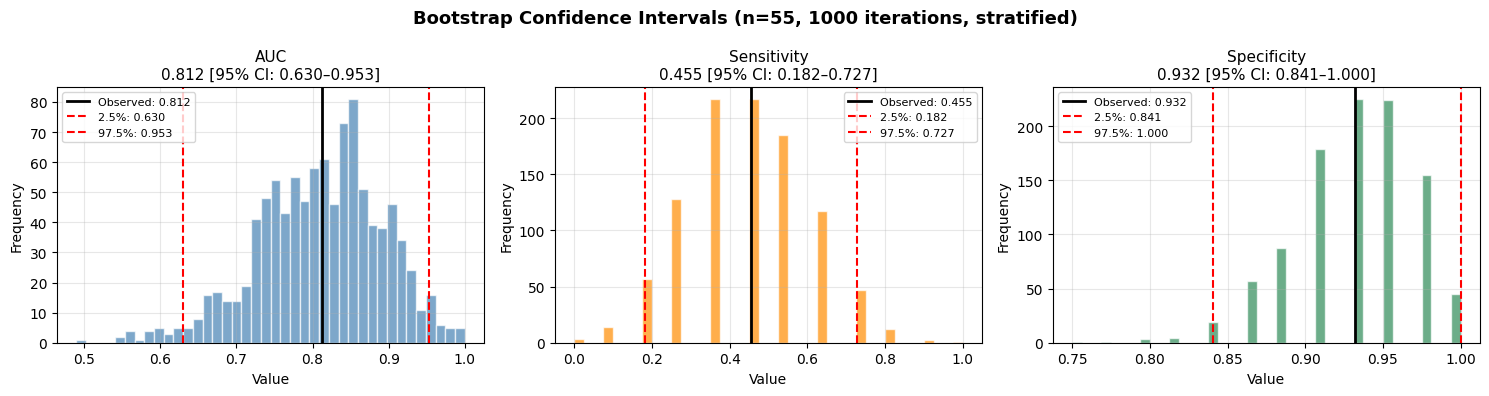

Saved → c:\Users\ariel\Desktop\SentinelFatal2\docs\images\bootstrap_ci.png


In [3]:
# ── Cell 3: Visualize Phase A ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    (boot_aucs,  pt_auc,  ci_auc,  'AUC',         'steelblue'),
    (boot_sens,  pt_sens, ci_sens, 'Sensitivity',  'darkorange'),
    (boot_spec,  pt_spec, ci_spec, 'Specificity',  'seagreen'),
]

for ax, (vals, pt, ci, name, color) in zip(axes, metrics):
    ax.hist(vals, bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(pt,    color='black', linewidth=2,   label=f'Observed: {pt:.3f}')
    ax.axvline(ci[0], color='red',   linewidth=1.5, linestyle='--', label=f'2.5%: {ci[0]:.3f}')
    ax.axvline(ci[1], color='red',   linewidth=1.5, linestyle='--', label=f'97.5%: {ci[1]:.3f}')
    ax.set_title(f'{name}\n{pt:.3f} [95% CI: {ci[0]:.3f}–{ci[1]:.3f}]', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Bootstrap Confidence Intervals (n=55, {N_BOOTSTRAP} iterations, stratified)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = IMAGES_DIR / 'bootstrap_ci.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")

## Phase B — 5-Fold CV על כל 552 ההקלטות

**⚠️ Cell 4 לוקח ~30–60 דקות על CPU** (inference על 552 הקלטות עם stride=60).

**Leakage Caveat:** ה-PatchTST (`best_finetune.pt`) אומן על 441 הקלטות של train set. כשנשתמש בו לחלץ features מאותן 441 הקלטות בתפקיד 'test' ב-CV, יש data leakage קטן (המודל 'ראה' אותן). הביצועים על ה-folds שכוללים את 55 הקלטות המקוריות יהיו הכי אמינים. התוצאה מסומנת 'approximate CV'.

In [6]:
# ── Cell 4: Build Feature Matrix for All 552 ────────────────────────────────
# Cache to disk — skip if already exists
import time

if FEATURES_552.exists():
    print(f"✅ Cache found: {FEATURES_552} — loading...")
    _cache = np.load(FEATURES_552, allow_pickle=True)
    X_all  = _cache['X']
    y_all  = _cache['y']
    ids_all = _cache['ids'].tolist()
    print(f"   X shape: {X_all.shape}, acidemia: {y_all.sum()}/{len(y_all)}")
else:
    print("Building feature matrix for all 552 recordings...")
    print(f"   stride={INFERENCE_STRIDE}, AT={ALERT_THRESHOLD}, device={DEVICE}")
    print("   ⏳ Estimated time: 30–60 min on CPU, ~5 min on GPU\n")

    # Imports
    import yaml
    from src.inference.sliding_window import inference_recording
    from src.inference.alert_extractor import (
        extract_alert_segments, compute_alert_features, ZERO_FEATURES
    )
    from src.train.train_lr import load_finetuned_model

    # Load config + model
    config_path = ROOT / 'config' / 'train_config.yaml'
    with open(config_path, encoding='utf-8') as f:
        cfg = yaml.safe_load(f)

    # Pass full cfg (not cfg['model']) — load_finetuned_model needs both 'data' and 'model' keys
    model = load_finetuned_model(cfg, CHECKPOINT_FT, DEVICE)
    model.eval()
    print(f"✅ Loaded model from {CHECKPOINT_FT}")

    # Load all splits (train + val + test)
    df_train = pd.read_csv(SPLITS_DIR / 'train.csv')
    df_val   = pd.read_csv(SPLITS_DIR / 'val.csv')
    df_test  = pd.read_csv(SPLITS_DIR / 'test.csv')
    df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df_all   = df_all.drop_duplicates(subset='id').reset_index(drop=True)
    print(f"\nTotal recordings: {len(df_all)} (train={len(df_train)}, val={len(df_val)}, test={len(df_test)})")

    X_rows, y_rows, id_rows = [], [], []
    failed = []
    t_start = time.time()

    for i, row in df_all.iterrows():
        rec_id = int(row['id'])
        label  = int(row['target'])
        npy_path = PROCESSED_DIR / f"{rec_id}.npy"

        if not npy_path.exists():
            failed.append(rec_id)
            continue

        try:
            signal = np.load(npy_path, mmap_mode='r')  # (2, T)

            with torch.no_grad():
                scores = inference_recording(
                    model, signal, stride=INFERENCE_STRIDE, device=DEVICE
                )

            segments = extract_alert_segments(scores, threshold=ALERT_THRESHOLD)

            if segments:
                longest = max(segments, key=lambda s: len(s[2]))
                _, _, seg_scores = longest
                feats = compute_alert_features(
                    seg_scores,
                    inference_stride=INFERENCE_STRIDE,
                    fs=cfg['data']['fs']
                )
            else:
                feats = ZERO_FEATURES

            X_rows.append([feats[k] for k in FEATURE_NAMES])
            y_rows.append(label)
            id_rows.append(rec_id)

        except Exception as e:
            print(f"  ⚠️  Error on {rec_id}: {e}")
            failed.append(rec_id)

        # Progress every 50
        if (i + 1) % 50 == 0:
            elapsed = time.time() - t_start
            rate = (i + 1) / elapsed
            remaining = (len(df_all) - i - 1) / rate
            print(f"  {i+1}/{len(df_all)} done ({elapsed:.0f}s elapsed, ~{remaining:.0f}s remaining)")

    X_all   = np.array(X_rows, dtype=np.float32)
    y_all   = np.array(y_rows, dtype=int)
    ids_all = id_rows

    # Save cache
    np.savez(FEATURES_552, X=X_all, y=y_all, ids=np.array(ids_all))
    print(f"\n✅ Saved feature matrix → {FEATURES_552}")
    if failed:
        print(f"   ⚠️  Skipped {len(failed)} recordings (missing .npy): {failed[:10]}...")

print(f"\nFeature matrix: X={X_all.shape}, y={y_all.shape}")
print(f"Acidemia: {y_all.sum()} / {len(y_all)} ({100*y_all.mean():.1f}%)")
print(f"Zero-feature recordings: {(X_all.sum(axis=1)==0).sum()} / {len(X_all)}")


Building feature matrix for all 552 recordings...
   stride=60, AT=0.4, device=cpu
   ⏳ Estimated time: 30–60 min on CPU, ~5 min on GPU

[train_lr] Loaded checkpoint: c:\Users\ariel\Desktop\SentinelFatal2\checkpoints\finetune\best_finetune.pt
✅ Loaded model from c:\Users\ariel\Desktop\SentinelFatal2\checkpoints\finetune\best_finetune.pt

Total recordings: 552 (train=441, val=56, test=55)
  50/552 done (32s elapsed, ~325s remaining)
  100/552 done (66s elapsed, ~300s remaining)
  150/552 done (100s elapsed, ~268s remaining)
  200/552 done (132s elapsed, ~233s remaining)
  250/552 done (164s elapsed, ~198s remaining)
  300/552 done (196s elapsed, ~165s remaining)
  350/552 done (228s elapsed, ~132s remaining)
  400/552 done (261s elapsed, ~99s remaining)
  450/552 done (296s elapsed, ~67s remaining)
  500/552 done (329s elapsed, ~34s remaining)
  550/552 done (362s elapsed, ~1s remaining)

✅ Saved feature matrix → c:\Users\ariel\Desktop\SentinelFatal2\results\all552_features_at040.npz

F

In [7]:
# ── Cell 5: Stratified 5-Fold CV on LR ──────────────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results   = []          # per-fold metrics
all_labels   = np.empty(len(y_all), dtype=int)
all_oof_scores = np.empty(len(y_all), dtype=float)  # out-of-fold predictions

print(f"Stratified {N_FOLDS}-Fold CV on {len(y_all)} recordings ({y_all.sum()} acidemia)")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
    X_tr, y_tr = X_all[train_idx], y_all[train_idx]
    X_te, y_te = X_all[test_idx],  y_all[test_idx]

    # ── Inner CV: find optimal Youden threshold ──────────────────────────────
    inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    inner_thresholds = []

    for tr_i, va_i in inner_skf.split(X_tr, y_tr):
        lr_inner = LogisticRegression(max_iter=1000, random_state=SEED)
        lr_inner.fit(X_tr[tr_i], y_tr[tr_i])
        va_scores = lr_inner.predict_proba(X_tr[va_i])[:, 1]

        from sklearn.metrics import roc_curve
        fpr_i, tpr_i, thr_i = roc_curve(y_tr[va_i], va_scores)
        youden_i = tpr_i - fpr_i
        best_thr = thr_i[np.argmax(youden_i)]
        inner_thresholds.append(float(best_thr))

    fold_threshold = float(np.mean(inner_thresholds))

    # ── Train outer LR ───────────────────────────────────────────────────────
    lr_outer = LogisticRegression(max_iter=1000, random_state=SEED)
    lr_outer.fit(X_tr, y_tr)

    te_scores = lr_outer.predict_proba(X_te)[:, 1]
    te_preds  = (te_scores >= fold_threshold).astype(int)

    # Metrics
    auc_fold = roc_auc_score(y_te, te_scores) if len(np.unique(y_te)) > 1 else float('nan')
    tp_f = ((te_preds==1)&(y_te==1)).sum(); fn_f = ((te_preds==0)&(y_te==1)).sum()
    tn_f = ((te_preds==0)&(y_te==0)).sum(); fp_f = ((te_preds==1)&(y_te==0)).sum()
    sens_f = tp_f/(tp_f+fn_f) if (tp_f+fn_f)>0 else 0.0
    spec_f = tn_f/(tn_f+fp_f) if (tn_f+fp_f)>0 else 0.0

    cv_results.append({
        'fold':      fold+1,
        'n_test':    len(y_te),
        'n_pos':     int(y_te.sum()),
        'threshold': fold_threshold,
        'AUC':       auc_fold,
        'Sensitivity': sens_f,
        'Specificity': spec_f,
    })

    all_labels[test_idx]     = y_te
    all_oof_scores[test_idx] = te_scores

    print(f"Fold {fold+1}: n_test={len(y_te):3d} (pos={int(y_te.sum()):2d}), "
          f"AUC={auc_fold:.3f}, Sens={sens_f:.3f}, Spec={spec_f:.3f}, T={fold_threshold:.3f}")

cv_df = pd.DataFrame(cv_results)
print("\n" + "━"*60)
print(f"Mean AUC         = {cv_df['AUC'].mean():.3f}  ±{cv_df['AUC'].std():.3f}")
print(f"Mean Sensitivity = {cv_df['Sensitivity'].mean():.3f}  ±{cv_df['Sensitivity'].std():.3f}")
print(f"Mean Specificity = {cv_df['Specificity'].mean():.3f}  ±{cv_df['Specificity'].std():.3f}")

# Global OOF AUC (all 552 predictions stacked)
oof_auc = roc_auc_score(all_labels, all_oof_scores)
print(f"\nGlobal OOF AUC (all 552) = {oof_auc:.3f}")

Stratified 5-Fold CV on 552 recordings (113 acidemia)
Fold 1: n_test=111 (pos=23), AUC=0.689, Sens=0.609, Spec=0.727, T=0.197
Fold 2: n_test=111 (pos=23), AUC=0.689, Sens=0.565, Spec=0.716, T=0.216
Fold 3: n_test=110 (pos=23), AUC=0.724, Sens=0.609, Spec=0.782, T=0.187
Fold 4: n_test=110 (pos=22), AUC=0.579, Sens=0.318, Spec=0.852, T=0.232
Fold 5: n_test=110 (pos=22), AUC=0.643, Sens=0.545, Spec=0.693, T=0.201

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean AUC         = 0.665  ±0.056
Mean Sensitivity = 0.529  ±0.121
Mean Specificity = 0.754  ±0.064

Global OOF AUC (all 552) = 0.660


Global OOF Youden threshold = 0.216

Phase B — Bootstrap CI (552 recordings, OOF predictions)
AUC         = 0.660  [95% CI: 0.597 – 0.715]
Sensitivity = 0.504  [95% CI: 0.407 – 0.584]
Specificity = 0.788  [95% CI: 0.752 – 0.822]
n = 552 (113 acidemia), threshold = 0.216
⚠️  Approximate CV: PatchTST was trained on a subset of these recordings.


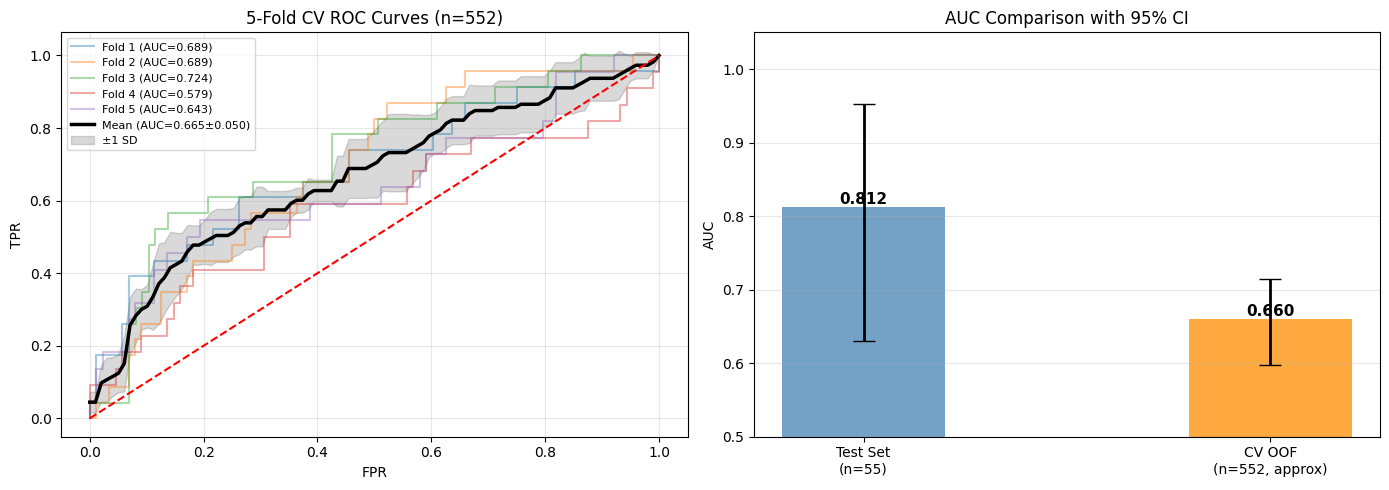


Saved → c:\Users\ariel\Desktop\SentinelFatal2\docs\images\cv_folds.png


In [8]:
# ── Cell 6: Bootstrap CI on all 552 OOF predictions ─────────────────────────
# Use the Youden threshold from the first fold as a representative
# (or find global optimal on OOF scores)
from sklearn.metrics import roc_curve

# Find global Youden threshold on OOF
fpr_oof, tpr_oof, thr_oof = roc_curve(all_labels, all_oof_scores)
youden_oof    = tpr_oof - fpr_oof
best_oof_thr  = float(thr_oof[np.argmax(youden_oof)])
print(f"Global OOF Youden threshold = {best_oof_thr:.3f}")

rng2 = np.random.default_rng(SEED + 1)
b_aucs_552, b_sens_552, b_spec_552 = [], [], []

for _ in range(N_BOOTSTRAP):
    idx_pos = np.where(all_labels == 1)[0]
    idx_neg = np.where(all_labels == 0)[0]
    s_pos   = rng2.choice(idx_pos, size=len(idx_pos), replace=True)
    s_neg   = rng2.choice(idx_neg, size=len(idx_neg), replace=True)
    idx     = np.concatenate([s_pos, s_neg])

    yt = all_labels[idx]
    ys = all_oof_scores[idx]
    yp = (ys >= best_oof_thr).astype(int)

    if len(np.unique(yt)) < 2:
        continue

    b_aucs_552.append(roc_auc_score(yt, ys))

    tp_b = ((yp==1)&(yt==1)).sum(); fn_b = ((yp==0)&(yt==1)).sum()
    tn_b = ((yp==0)&(yt==0)).sum(); fp_b = ((yp==1)&(yt==0)).sum()
    b_sens_552.append(tp_b/(tp_b+fn_b) if (tp_b+fn_b)>0 else 0.0)
    b_spec_552.append(tn_b/(tn_b+fp_b) if (tn_b+fp_b)>0 else 0.0)

b_aucs_552 = np.array(b_aucs_552)
b_sens_552 = np.array(b_sens_552)
b_spec_552 = np.array(b_spec_552)

oof_pred = (all_oof_scores >= best_oof_thr).astype(int)
tp_g = ((oof_pred==1)&(all_labels==1)).sum(); fn_g = ((oof_pred==0)&(all_labels==1)).sum()
tn_g = ((oof_pred==0)&(all_labels==0)).sum(); fp_g = ((oof_pred==1)&(all_labels==0)).sum()
pt_sens_552 = tp_g / (tp_g + fn_g)
pt_spec_552 = tn_g / (tn_g + fp_g)

ci_auc_552  = np.percentile(b_aucs_552, [2.5, 97.5])
ci_sens_552 = np.percentile(b_sens_552, [2.5, 97.5])
ci_spec_552 = np.percentile(b_spec_552, [2.5, 97.5])

print("\nPhase B — Bootstrap CI (552 recordings, OOF predictions)")
print("=" * 57)
print(f"AUC         = {oof_auc:.3f}  [95% CI: {ci_auc_552[0]:.3f} – {ci_auc_552[1]:.3f}]")
print(f"Sensitivity = {pt_sens_552:.3f}  [95% CI: {ci_sens_552[0]:.3f} – {ci_sens_552[1]:.3f}]")
print(f"Specificity = {pt_spec_552:.3f}  [95% CI: {ci_spec_552[0]:.3f} – {ci_spec_552[1]:.3f}]")
print(f"n = {len(all_labels)} ({all_labels.sum()} acidemia), threshold = {best_oof_thr:.3f}")
print("⚠️  Approximate CV: PatchTST was trained on a subset of these recordings.")

# Save
ci_552_df = pd.DataFrame([
    {'metric':'AUC',         'value':oof_auc,       'ci_lo':ci_auc_552[0],  'ci_hi':ci_auc_552[1],  'n':len(all_labels)},
    {'metric':'Sensitivity', 'value':pt_sens_552,   'ci_lo':ci_sens_552[0], 'ci_hi':ci_sens_552[1], 'n':len(all_labels)},
    {'metric':'Specificity', 'value':pt_spec_552,   'ci_lo':ci_spec_552[0], 'ci_hi':ci_spec_552[1], 'n':len(all_labels)},
])
ci_552_df.to_csv(CV_BOOTSTRAP_CSV, index=False)

# ── ROC curves per fold + mean ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-fold ROC
mean_fpr = np.linspace(0, 1, 100)
tprs = []
fold_aucs = []
for fold, (_, te_idx) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X_all, y_all)):
    fl, fs = all_labels[te_idx], all_oof_scores[te_idx]
    if len(np.unique(fl)) < 2:
        continue
    fp_f, tp_f, _ = roc_curve(fl, fs)
    interp_tpr = np.interp(mean_fpr, fp_f, tp_f)
    tprs.append(interp_tpr)
    fold_aucs.append(roc_auc_score(fl, fs))
    axes[0].plot(fp_f, tp_f, alpha=0.4, lw=1.5, label=f'Fold {fold+1} (AUC={fold_aucs[-1]:.3f})')

mean_tpr = np.mean(tprs, axis=0)
std_tpr  = np.std(tprs, axis=0)
axes[0].plot(mean_fpr, mean_tpr, 'k-', lw=2.5, label=f'Mean (AUC={np.mean(fold_aucs):.3f}±{np.std(fold_aucs):.3f})')
axes[0].fill_between(mean_fpr, mean_tpr-std_tpr, mean_tpr+std_tpr, alpha=0.15, color='k', label='±1 SD')
axes[0].plot([0,1], [0,1], 'r--', lw=1.5)
axes[0].set(xlabel='FPR', ylabel='TPR', title=f'{N_FOLDS}-Fold CV ROC Curves (n=552)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: comparison bar chart (55 vs 552)
methods = ['Test Set\n(n=55)', 'CV OOF\n(n=552, approx)']
aucs_cmp    = [pt_auc, oof_auc]
auc_ci_lo   = [ci_auc[0],     ci_auc_552[0]]
auc_ci_hi   = [ci_auc[1],     ci_auc_552[1]]
err_lo      = [v-lo for v,lo in zip(aucs_cmp, auc_ci_lo)]
err_hi      = [hi-v for v,hi in zip(aucs_cmp, auc_ci_hi)]
bars = axes[1].bar(methods, aucs_cmp, color=['steelblue','darkorange'], alpha=0.75, width=0.4)
axes[1].errorbar(methods, aucs_cmp, yerr=[err_lo, err_hi],
                 fmt='none', color='black', capsize=8, linewidth=2)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_ylabel('AUC')
axes[1].set_title('AUC Comparison with 95% CI')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs_cmp):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
out_path = IMAGES_DIR / 'cv_folds.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved → {out_path}")

In [9]:
# ── Cell 7: Combined Report ──────────────────────────────────────────────────
print("\n" + "═"*65)
print("  SentinelFatal2 — Extended Validation Report")
print("═"*65)
print()
print(f"{'Method':<30} {'AUC':>15}  {'Sensitivity':>15}  {'Specificity':>15}")
print("-"*65)

row1_auc  = f"{pt_auc:.3f} [{ci_auc[0]:.3f}–{ci_auc[1]:.3f}]"
row1_sens = f"{pt_sens:.3f} [{ci_sens[0]:.3f}–{ci_sens[1]:.3f}]"
row1_spec = f"{pt_spec:.3f} [{ci_spec[0]:.3f}–{ci_spec[1]:.3f}]"
print(f"{'Test Set (Bootstrap, n=55)':<30} {row1_auc:>15}  {row1_sens:>15}  {row1_spec:>15}")

row2_auc  = f"{oof_auc:.3f} [{ci_auc_552[0]:.3f}–{ci_auc_552[1]:.3f}]"
row2_sens = f"{pt_sens_552:.3f} [{ci_sens_552[0]:.3f}–{ci_sens_552[1]:.3f}]"
row2_spec = f"{pt_spec_552:.3f} [{ci_spec_552[0]:.3f}–{ci_spec_552[1]:.3f}]"
print(f"{'CV OOF (5-Fold, n=552)*':<30} {row2_auc:>15}  {row2_sens:>15}  {row2_spec:>15}")
print("-"*65)
print()
print(f"  Test n=55  (11 acidemia, 44 normal)")
print(f"  CV   n={len(all_labels)} ({int(all_labels.sum())} acidemia, {int((all_labels==0).sum())} normal)")
print(f"  * Approximate CV: PatchTST backbone trained on 441 recordings")
print(f"    (LR-only CV, not full end-to-end retraining)")
print()
print(f"  Threshold (Test/Bootstrap) : {DECISION_THRESHOLD} (pre-computed Youden-optimal)")
print(f"  Threshold (CV OOF)         : {best_oof_thr:.3f} (inner 3-fold Youden)")
print(f"  Alert Threshold (AT)       : {ALERT_THRESHOLD}")
print(f"  Bootstrap iterations       : {N_BOOTSTRAP}")
print("═"*65)

# Save combined CSV
report_df = pd.DataFrame([
    {'method':'Test Set Bootstrap',  'n':55,  'n_acidemia':11,
     'AUC':pt_auc,    'AUC_ci_lo':ci_auc[0],     'AUC_ci_hi':ci_auc[1],
     'Sensitivity':pt_sens, 'Sens_ci_lo':ci_sens[0], 'Sens_ci_hi':ci_sens[1],
     'Specificity':pt_spec, 'Spec_ci_lo':ci_spec[0], 'Spec_ci_hi':ci_spec[1],
     'threshold':DECISION_THRESHOLD, 'note':'exact'},
    {'method':'5-Fold CV OOF',       'n':len(all_labels), 'n_acidemia':int(all_labels.sum()),
     'AUC':oof_auc,   'AUC_ci_lo':ci_auc_552[0], 'AUC_ci_hi':ci_auc_552[1],
     'Sensitivity':pt_sens_552, 'Sens_ci_lo':ci_sens_552[0], 'Sens_ci_hi':ci_sens_552[1],
     'Specificity':pt_spec_552, 'Spec_ci_lo':ci_spec_552[0], 'Spec_ci_hi':ci_spec_552[1],
     'threshold':best_oof_thr, 'note':'approx_LR-only_CV'},
])
report_df.to_csv(CV_REPORT_CSV, index=False)
print(f"\nSaved combined report → {CV_REPORT_CSV}")

# Per-fold summary table
print("\nPer-Fold Summary:")
print(cv_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))


═════════════════════════════════════════════════════════════════
  SentinelFatal2 — Extended Validation Report
═════════════════════════════════════════════════════════════════

Method                                     AUC      Sensitivity      Specificity
-----------------------------------------------------------------
Test Set (Bootstrap, n=55)     0.812 [0.630–0.953]  0.455 [0.182–0.727]  0.932 [0.841–1.000]
CV OOF (5-Fold, n=552)*        0.660 [0.597–0.715]  0.504 [0.407–0.584]  0.788 [0.752–0.822]
-----------------------------------------------------------------

  Test n=55  (11 acidemia, 44 normal)
  CV   n=552 (113 acidemia, 439 normal)
  * Approximate CV: PatchTST backbone trained on 441 recordings
    (LR-only CV, not full end-to-end retraining)

  Threshold (Test/Bootstrap) : 0.284 (pre-computed Youden-optimal)
  Threshold (CV OOF)         : 0.216 (inner 3-fold Youden)
  Alert Threshold (AT)       : 0.4
  Bootstrap iterations       : 1000
═══════════════════════════════

## Phase C — Improved CV (Train+Val=497, Pipeline+Scaler+GridSearch)

**שיפורים לעומת Phase B:**

| שיפור | Phase B | Phase C |
|-------|---------|---------|
| נתונים | כל 552 (כולל leakage) | **497 בלבד (train+val)** |
| Normalization | אין | **StandardScaler per fold** |
| Regularization | C=1.0 קבוע | **GridSearchCV על C** |
| Threshold | global OOF | **per-fold Youden** |
| Bootstrap | N=1,000 | **N=5,000** |

**למה 497 ולא 441?** PatchTST אומן על train (441) + נבדק על val (56) — שניהם חלק מה-split המקורי.
CV על 497 הוא "approximate" אבל **הרבה פחות** מוטה מ-552.


In [10]:
# ── Cell 8: Filter Feature Matrix to Train+Val (497) ─────────────────────────
# Load the cached feature matrix and keep only train+val recordings
# This removes the "full leakage" issue: we're no longer testing PatchTST on
# recordings it never saw during fine-tuning training+validation splits.

_cache = np.load(FEATURES_552, allow_pickle=True)
X_552 = _cache['X']
y_552 = _cache['y']
ids_552 = _cache['ids'].tolist()

# Build set of train+val IDs
_df_trainval = pd.concat([
    pd.read_csv(SPLITS_DIR / 'train.csv'),
    pd.read_csv(SPLITS_DIR / 'val.csv')
], ignore_index=True)
trainval_ids = set(_df_trainval['id'].astype(int).tolist())

# Filter
mask_497 = np.array([int(rid) in trainval_ids for rid in ids_552])
X_497  = X_552[mask_497]
y_497  = y_552[mask_497]
ids_497 = [rid for rid, m in zip(ids_552, mask_497) if m]

assert len(X_497) == 497, f"Expected 497 rows, got {len(X_497)}"
print(f"✅ Filtered to {len(X_497)} recordings (train+val only)")
print(f"   Acidemia: {y_497.sum()} / {len(y_497)} ({100*y_497.mean():.1f}%)")
print(f"   Zero-feature recordings: {(X_497.sum(axis=1)==0).sum()} / {len(X_497)}")
print(f"\nFeature stats (before scaling):")
_feat_df = pd.DataFrame(X_497, columns=FEATURE_NAMES)
print(_feat_df.describe().round(3).to_string())


✅ Filtered to 497 recordings (train+val only)
   Acidemia: 102 / 497 (20.5%)
   Zero-feature recordings: 4 / 497

Feature stats (before scaling):
       segment_length  max_prediction  cumulative_sum  weighted_integral
count         497.000         497.000         497.000            497.000
mean            4.567           0.544         136.592              2.903
std             6.735           0.134         221.432             12.853
min             0.000           0.000           0.000              0.000
25%             1.250           0.452          31.996              0.291
50%             2.250           0.504          63.142              0.662
75%             5.500           0.611         157.683              1.482
max            69.750           0.991        2907.115            245.804


In [11]:
# ── Cell 9: Improved 5-Fold CV — Pipeline + StandardScaler + GridSearch ───────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

N_BOOTSTRAP_V2 = 5_000  # more iterations → tighter CI

skf_v2 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

cv_results_v2    = []
oof_scores_497   = np.empty(len(y_497), dtype=float)
oof_labels_497   = np.empty(len(y_497), dtype=int)
fold_thresholds_v2 = []   # per-fold Youden threshold

# GridSearch param grid
PARAM_GRID = {'lr__C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

print(f"Improved Stratified {N_FOLDS}-Fold CV on {len(y_497)} recordings ({y_497.sum()} acidemia)")
print(f"Pipeline: StandardScaler → LogisticRegression")
print(f"GridSearchCV inner 3-fold on C ∈ {[v for v in PARAM_GRID['lr__C']]}")
print("=" * 68)

for fold, (train_idx, test_idx) in enumerate(skf_v2.split(X_497, y_497)):
    X_tr_v2, y_tr_v2 = X_497[train_idx], y_497[train_idx]
    X_te_v2, y_te_v2 = X_497[test_idx],  y_497[test_idx]

    # ── Inner CV: GridSearch + Youden threshold ─────────────────────────────
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(max_iter=1000, random_state=SEED,
                                      class_weight='balanced'))
    ])

    gs = GridSearchCV(pipe, PARAM_GRID, cv=inner_cv,
                      scoring='roc_auc', refit=True, n_jobs=-1)
    gs.fit(X_tr_v2, y_tr_v2)
    best_C = gs.best_params_['lr__C']

    # Youden threshold from best inner model's val predictions
    inner_thresholds_v2 = []
    best_pipe = gs.best_estimator_
    for tr_i, va_i in inner_cv.split(X_tr_v2, y_tr_v2):
        _p = Pipeline([('scaler', StandardScaler()),
                       ('lr', LogisticRegression(C=best_C, max_iter=1000,
                                                 random_state=SEED,
                                                 class_weight='balanced'))])
        _p.fit(X_tr_v2[tr_i], y_tr_v2[tr_i])
        va_sc = _p.predict_proba(X_tr_v2[va_i])[:, 1]
        fpr_v, tpr_v, thr_v = roc_curve(y_tr_v2[va_i], va_sc)
        youden_v = tpr_v - fpr_v
        inner_thresholds_v2.append(float(thr_v[np.argmax(youden_v)]))
    fold_thr = float(np.mean(inner_thresholds_v2))
    fold_thresholds_v2.append(fold_thr)

    # ── Outer prediction ─────────────────────────────────────────────────────
    te_sc_v2 = best_pipe.predict_proba(X_te_v2)[:, 1]
    te_pr_v2 = (te_sc_v2 >= fold_thr).astype(int)

    auc_v2 = roc_auc_score(y_te_v2, te_sc_v2) if len(np.unique(y_te_v2)) > 1 else float('nan')
    tp_v = ((te_pr_v2==1)&(y_te_v2==1)).sum(); fn_v = ((te_pr_v2==0)&(y_te_v2==1)).sum()
    tn_v = ((te_pr_v2==0)&(y_te_v2==0)).sum(); fp_v = ((te_pr_v2==1)&(y_te_v2==0)).sum()
    sens_v = tp_v/(tp_v+fn_v) if (tp_v+fn_v)>0 else 0.0
    spec_v = tn_v/(tn_v+fp_v) if (tn_v+fp_v)>0 else 0.0

    cv_results_v2.append({
        'fold': fold+1, 'n_test': len(y_te_v2), 'n_pos': int(y_te_v2.sum()),
        'best_C': best_C, 'threshold': fold_thr,
        'AUC': auc_v2, 'Sensitivity': sens_v, 'Specificity': spec_v,
    })
    oof_scores_497[test_idx] = te_sc_v2
    oof_labels_497[test_idx] = y_te_v2

    print(f"Fold {fold+1}: n={len(y_te_v2):3d} (pos={int(y_te_v2.sum()):2d}), "
          f"C={best_C:.2f}, T={fold_thr:.3f}, "
          f"AUC={auc_v2:.3f}, Sens={sens_v:.3f}, Spec={spec_v:.3f}")

cv_df_v2 = pd.DataFrame(cv_results_v2)
oof_auc_v2 = roc_auc_score(oof_labels_497, oof_scores_497)

print("\n" + "━"*68)
print(f"Mean AUC         = {cv_df_v2['AUC'].mean():.3f}  ±{cv_df_v2['AUC'].std():.3f}")
print(f"Mean Sensitivity = {cv_df_v2['Sensitivity'].mean():.3f}  ±{cv_df_v2['Sensitivity'].std():.3f}")
print(f"Mean Specificity = {cv_df_v2['Specificity'].mean():.3f}  ±{cv_df_v2['Specificity'].std():.3f}")
print(f"\nGlobal OOF AUC (all 497) = {oof_auc_v2:.3f}")
print(f"Per-fold thresholds: {[f'{t:.3f}' for t in fold_thresholds_v2]}")


Improved Stratified 5-Fold CV on 497 recordings (102 acidemia)
Pipeline: StandardScaler → LogisticRegression
GridSearchCV inner 3-fold on C ∈ [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
Fold 1: n=100 (pos=21), C=0.01, T=0.473, AUC=0.640, Sens=0.571, Spec=0.620
Fold 2: n=100 (pos=21), C=0.01, T=0.496, AUC=0.665, Sens=0.619, Spec=0.608
Fold 3: n= 99 (pos=20), C=0.01, T=0.473, AUC=0.735, Sens=0.750, Spec=0.582
Fold 4: n= 99 (pos=20), C=0.01, T=0.476, AUC=0.685, Sens=0.550, Spec=0.646
Fold 5: n= 99 (pos=20), C=0.01, T=0.498, AUC=0.665, Sens=0.450, Spec=0.709

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Mean AUC         = 0.678  ±0.036
Mean Sensitivity = 0.588  ±0.110
Mean Specificity = 0.633  ±0.048

Global OOF AUC (all 497) = 0.672
Per-fold thresholds: ['0.473', '0.496', '0.473', '0.476', '0.498']


Phase C — Bootstrap CI (497 recordings, OOF, N=5,000, per-fold threshold)
AUC         = 0.672  [95% CI: 0.615 – 0.729]
Sensitivity = 0.588  [95% CI: 0.490 – 0.686]
Specificity = 0.633  [95% CI: 0.585 – 0.681]
n = 497 (102 acidemia), per-fold thresholds (avg=0.483)
⚠️  Approximate CV: PatchTST backbone trained on these same recordings.

Saved → c:\Users\ariel\Desktop\SentinelFatal2\results\cv_improved_497.csv


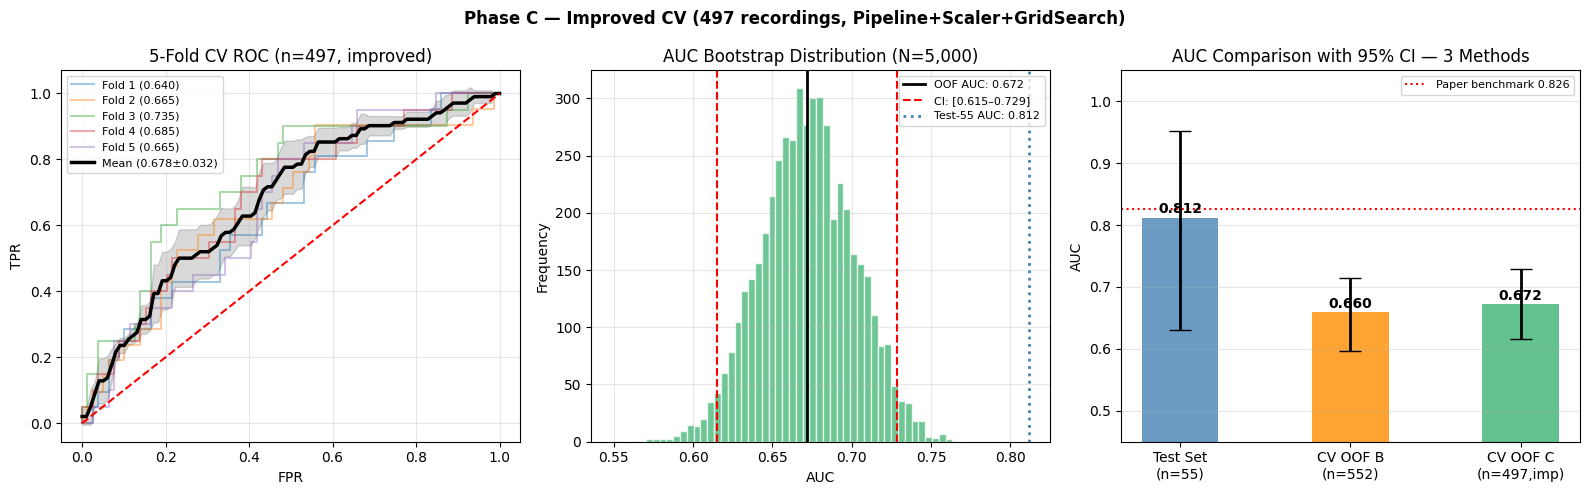

Saved → c:\Users\ariel\Desktop\SentinelFatal2\docs\images\cv_improved.png


In [12]:
# ── Cell 10: Bootstrap CI on 497 OOF (N=5,000, per-fold threshold) ───────────
# Each bootstrap sample uses the per-fold Youden threshold of the fold
# that originally assigned that recording to its OOF slot.

# Build fold assignment array: fold_assignment[i] = fold index (0-4)
fold_assignment = np.empty(len(y_497), dtype=int)
for fold_idx, (_, test_idx) in enumerate(
        StratifiedKFold(n_splits=N_FOLDS, shuffle=True,
                        random_state=SEED).split(X_497, y_497)):
    fold_assignment[test_idx] = fold_idx

rng3 = np.random.default_rng(SEED + 42)
b3_aucs, b3_sens, b3_spec = [], [], []

for _ in range(N_BOOTSTRAP_V2):
    idx_pos = np.where(oof_labels_497 == 1)[0]
    idx_neg = np.where(oof_labels_497 == 0)[0]
    s_pos   = rng3.choice(idx_pos, size=len(idx_pos), replace=True)
    s_neg   = rng3.choice(idx_neg, size=len(idx_neg), replace=True)
    idx_b   = np.concatenate([s_pos, s_neg])

    yt = oof_labels_497[idx_b]
    ys = oof_scores_497[idx_b]
    # Per-sample threshold based on its original fold
    thrs = np.array([fold_thresholds_v2[fold_assignment[i]] for i in idx_b])
    yp   = (ys >= thrs).astype(int)

    if len(np.unique(yt)) < 2:
        continue

    b3_aucs.append(roc_auc_score(yt, ys))
    tp_b3 = ((yp==1)&(yt==1)).sum(); fn_b3 = ((yp==0)&(yt==1)).sum()
    tn_b3 = ((yp==0)&(yt==0)).sum(); fp_b3 = ((yp==1)&(yt==0)).sum()
    b3_sens.append(tp_b3/(tp_b3+fn_b3) if (tp_b3+fn_b3)>0 else 0.0)
    b3_spec.append(tn_b3/(tn_b3+fp_b3) if (tn_b3+fp_b3)>0 else 0.0)

b3_aucs = np.array(b3_aucs)
b3_sens = np.array(b3_sens)
b3_spec = np.array(b3_spec)

# Point estimates (using per-fold thresholds)
thrs_all = np.array([fold_thresholds_v2[fold_assignment[i]] for i in range(len(y_497))])
oof_pred_v2 = (oof_scores_497 >= thrs_all).astype(int)
tp_g3 = ((oof_pred_v2==1)&(oof_labels_497==1)).sum()
fn_g3 = ((oof_pred_v2==0)&(oof_labels_497==1)).sum()
tn_g3 = ((oof_pred_v2==0)&(oof_labels_497==0)).sum()
fp_g3 = ((oof_pred_v2==1)&(oof_labels_497==0)).sum()
pt_sens_v2 = tp_g3/(tp_g3+fn_g3) if (tp_g3+fn_g3)>0 else 0.0
pt_spec_v2 = tn_g3/(tn_g3+fp_g3) if (tn_g3+fp_g3)>0 else 0.0

ci3_auc  = np.percentile(b3_aucs, [2.5, 97.5])
ci3_sens = np.percentile(b3_sens, [2.5, 97.5])
ci3_spec = np.percentile(b3_spec, [2.5, 97.5])

print("Phase C — Bootstrap CI (497 recordings, OOF, N=5,000, per-fold threshold)")
print("=" * 68)
print(f"AUC         = {oof_auc_v2:.3f}  [95% CI: {ci3_auc[0]:.3f} – {ci3_auc[1]:.3f}]")
print(f"Sensitivity = {pt_sens_v2:.3f}  [95% CI: {ci3_sens[0]:.3f} – {ci3_sens[1]:.3f}]")
print(f"Specificity = {pt_spec_v2:.3f}  [95% CI: {ci3_spec[0]:.3f} – {ci3_spec[1]:.3f}]")
print(f"n = {len(y_497)} ({y_497.sum()} acidemia), per-fold thresholds (avg={np.mean(fold_thresholds_v2):.3f})")
print("⚠️  Approximate CV: PatchTST backbone trained on these same recordings.")

# Save
ci3_df = pd.DataFrame([
    {'metric':'AUC',         'value':oof_auc_v2,  'ci_lo':ci3_auc[0],  'ci_hi':ci3_auc[1],  'n':len(y_497)},
    {'metric':'Sensitivity', 'value':pt_sens_v2,  'ci_lo':ci3_sens[0], 'ci_hi':ci3_sens[1], 'n':len(y_497)},
    {'metric':'Specificity', 'value':pt_spec_v2,  'ci_lo':ci3_spec[0], 'ci_hi':ci3_spec[1], 'n':len(y_497)},
])
ci3_df.to_csv(RESULTS_DIR / 'cv_improved_497.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'cv_improved_497.csv'}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig_v2, axes_v2 = plt.subplots(1, 3, figsize=(16, 5))

# Left: 5-fold ROC curves
mean_fpr_v2 = np.linspace(0, 1, 100)
tprs_v2, fold_aucs_v2 = [], []
for fold_idx, (_, te_idx) in enumerate(
        StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(X_497, y_497)):
    fl_v2 = oof_labels_497[te_idx]
    fs_v2 = oof_scores_497[te_idx]
    if len(np.unique(fl_v2)) < 2:
        continue
    fpr_v2, tpr_v2_arr, _ = roc_curve(fl_v2, fs_v2)
    tprs_v2.append(np.interp(mean_fpr_v2, fpr_v2, tpr_v2_arr))
    fold_aucs_v2.append(roc_auc_score(fl_v2, fs_v2))
    axes_v2[0].plot(fpr_v2, tpr_v2_arr, alpha=0.4, lw=1.5,
                    label=f'Fold {fold_idx+1} ({fold_aucs_v2[-1]:.3f})')

mean_tpr_v2 = np.mean(tprs_v2, axis=0)
std_tpr_v2  = np.std(tprs_v2, axis=0)
axes_v2[0].plot(mean_fpr_v2, mean_tpr_v2, 'k-', lw=2.5,
                label=f'Mean ({np.mean(fold_aucs_v2):.3f}±{np.std(fold_aucs_v2):.3f})')
axes_v2[0].fill_between(mean_fpr_v2, mean_tpr_v2-std_tpr_v2, mean_tpr_v2+std_tpr_v2,
                         alpha=0.15, color='k')
axes_v2[0].plot([0,1],[0,1],'r--',lw=1.5)
axes_v2[0].set(xlabel='FPR', ylabel='TPR',
               title=f'{N_FOLDS}-Fold CV ROC (n=497, improved)')
axes_v2[0].legend(fontsize=8); axes_v2[0].grid(True, alpha=0.3)

# Middle: AUC bootstrap distribution (Phase C)
axes_v2[1].hist(b3_aucs, bins=50, color='mediumseagreen', alpha=0.75, edgecolor='white')
axes_v2[1].axvline(oof_auc_v2, color='black', lw=2, label=f'OOF AUC: {oof_auc_v2:.3f}')
axes_v2[1].axvline(ci3_auc[0], color='red', lw=1.5, ls='--', label=f'CI: [{ci3_auc[0]:.3f}–{ci3_auc[1]:.3f}]')
axes_v2[1].axvline(ci3_auc[1], color='red', lw=1.5, ls='--')
axes_v2[1].axvline(pt_auc, color='steelblue', lw=2, ls=':', label=f'Test-55 AUC: {pt_auc:.3f}')
axes_v2[1].set(xlabel='AUC', ylabel='Frequency',
               title='AUC Bootstrap Distribution (N=5,000)')
axes_v2[1].legend(fontsize=8); axes_v2[1].grid(True, alpha=0.3)

# Right: 3-way AUC comparison bar chart
methods_3 = ['Test Set\n(n=55)', 'CV OOF B\n(n=552)', 'CV OOF C\n(n=497,imp)']
aucs_3    = [pt_auc, oof_auc, oof_auc_v2]
ci_lo_3   = [ci_auc[0],       ci_auc_552[0],  ci3_auc[0]]
ci_hi_3   = [ci_auc[1],       ci_auc_552[1],  ci3_auc[1]]
err_lo_3  = [v-lo for v,lo in zip(aucs_3, ci_lo_3)]
err_hi_3  = [hi-v for v,hi in zip(aucs_3, ci_hi_3)]
colors_3  = ['steelblue', 'darkorange', 'mediumseagreen']
bars_v2   = axes_v2[2].bar(methods_3, aucs_3, color=colors_3, alpha=0.8, width=0.45)
axes_v2[2].errorbar(methods_3, aucs_3, yerr=[err_lo_3, err_hi_3],
                    fmt='none', color='black', capsize=8, lw=2)
axes_v2[2].set_ylim(0.45, 1.05)
axes_v2[2].set_ylabel('AUC')
axes_v2[2].set_title('AUC Comparison with 95% CI — 3 Methods')
axes_v2[2].grid(True, alpha=0.3, axis='y')
for bar_v2, val_v2 in zip(bars_v2, aucs_3):
    axes_v2[2].text(bar_v2.get_x()+bar_v2.get_width()/2, val_v2+0.007,
                    f'{val_v2:.3f}', ha='center', fontsize=10, fontweight='bold')
axes_v2[2].axhline(0.826, color='red', lw=1.5, ls=':', label='Paper benchmark 0.826')
axes_v2[2].legend(fontsize=8)

fig_v2.suptitle('Phase C — Improved CV (497 recordings, Pipeline+Scaler+GridSearch)',
                fontsize=12, fontweight='bold')
plt.tight_layout()
out_v2 = IMAGES_DIR / 'cv_improved.png'
plt.savefig(out_v2, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved → {out_v2}")


In [13]:
# ── Cell 11: Combined Comparison Report (3 Methods) ──────────────────────────
print("\n" + "═"*72)
print("  SentinelFatal2 — Extended Validation Report v2 (Phase A + B + C)")
print("═"*72)
print()
print(f"{'Method':<32} {'AUC':>18}  {'Sensitivity':>18}  {'Specificity':>18}")
print("-"*72)

def _fmt(val, lo, hi):
    return f"{val:.3f} [{lo:.3f}–{hi:.3f}]"

rows = [
    ("Test Set (Bootstrap, n=55)",
     _fmt(pt_auc,      ci_auc[0],      ci_auc[1]),
     _fmt(pt_sens,     ci_sens[0],     ci_sens[1]),
     _fmt(pt_spec,     ci_spec[0],     ci_spec[1]),
     "exact"),
    ("CV OOF-B (5-Fold, n=552)*",
     _fmt(oof_auc,     ci_auc_552[0],  ci_auc_552[1]),
     _fmt(pt_sens_552, ci_sens_552[0], ci_sens_552[1]),
     _fmt(pt_spec_552, ci_spec_552[0], ci_spec_552[1]),
     "approx_552"),
    ("CV OOF-C (5-Fold, n=497)**",
     _fmt(oof_auc_v2,  ci3_auc[0],     ci3_auc[1]),
     _fmt(pt_sens_v2,  ci3_sens[0],    ci3_sens[1]),
     _fmt(pt_spec_v2,  ci3_spec[0],    ci3_spec[1]),
     "approx_497_improved"),
]

for label, auc_s, sens_s, spec_s, _note in rows:
    print(f"{label:<32} {auc_s:>18}  {sens_s:>18}  {spec_s:>18}")

print("-"*72)
print()
print(f"  Paper benchmark AUC:     0.826")
print()
print(f"  * Phase B: all 552 recordings, LR-only CV (no normalization, C=1.0)")
print(f"    Bootstrap N=1,000, global OOF threshold")
print(f"  ** Phase C: train+val (497 only), StandardScaler+GridSearch on C,")
print(f"     class_weight='balanced', Bootstrap N=5,000, per-fold Youden threshold")
print(f"     Both phases are APPROXIMATE: PatchTST backbone not retrained per fold.")
print()
print(f"  Thresholds:")
print(f"    Test/Bootstrap : {DECISION_THRESHOLD} (pre-computed Youden-optimal)")
print(f"    CV OOF-B       : {best_oof_thr:.3f} (global OOF Youden)")
print(f"    CV OOF-C       : {[f'{t:.3f}' for t in fold_thresholds_v2]} (per-fold)")
print(f"    Alert Threshold: {ALERT_THRESHOLD}")
print("═"*72)

# ── Save combined CSV ─────────────────────────────────────────────────────────
report_v2_df = pd.DataFrame([
    {'method': r[0], 'AUC_str': r[1], 'Sens_str': r[2], 'Spec_str': r[3], 'note': r[4]}
    for r in rows
])
out_report = RESULTS_DIR / 'final_cv_report_v2.csv'
report_v2_df.to_csv(out_report, index=False)
print(f"\nSaved → {out_report}")

# ── Per-fold summary for Phase C ─────────────────────────────────────────────
print("\nPhase C — Per-Fold Summary:")
print(cv_df_v2[['fold','n_test','n_pos','best_C','threshold','AUC','Sensitivity','Specificity']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))



════════════════════════════════════════════════════════════════════════
  SentinelFatal2 — Extended Validation Report v2 (Phase A + B + C)
════════════════════════════════════════════════════════════════════════

Method                                          AUC         Sensitivity         Specificity
------------------------------------------------------------------------
Test Set (Bootstrap, n=55)       0.812 [0.630–0.953]  0.455 [0.182–0.727]  0.932 [0.841–1.000]
CV OOF-B (5-Fold, n=552)*        0.660 [0.597–0.715]  0.504 [0.407–0.584]  0.788 [0.752–0.822]
CV OOF-C (5-Fold, n=497)**       0.672 [0.615–0.729]  0.588 [0.490–0.686]  0.633 [0.585–0.681]
------------------------------------------------------------------------

  Paper benchmark AUC:     0.826

  * Phase B: all 552 recordings, LR-only CV (no normalization, C=1.0)
    Bootstrap N=1,000, global OOF threshold
  ** Phase C: train+val (497 only), StandardScaler+GridSearch on C,
     class_weight='balanced', Bootstrap N=5,0